### Packages and Setup

In [13]:
import networkx as nx
import numpy as np
import random
import generative_functions as gf
import pandas as pd
seed = random.seed(78)

### Problem introduction

This project aims to compare the classification abilities and robustness of different models (Random Forest, SVM, GNN) and features to correctly classify (non-oriented) graphs generated from four different generative models : 
- the Erdös-Rényi random graphs model (ER), 
- the Barabasi-Albert preferential attachment model (BA), 
- the Watts-Strogatz small-world model (WS)
- the Stochastich Block Model (SBM).

We are going to conduct several experiments to assess those classification power and robustness :
- A baseline experiment were we don't constraint the graph density to be similar regardless of the model. This should lead to an easier classification but a poor generalization (and then poor robustness).
- A density-controlled experiment were we set the density to a given number for all the models. This should lead the classification models to leverage characteristics beyond the density or the average degree.
- A density-controlled experiment + training and test on graphs of different sizes ($n = 100$ for training and $n = 200$ for test). This allows to evaluate if the classification models are robust for graph of different (and unseen) sizes.
- A density-controlled experiment + random edge perturbations to see if
the models are robust to more realistic graphs (with errors and noise in the connections).

### Baseline Experiment 

No constraints on the generative model parameters to ensure a similar density.

Let's set the number of nodes per graph at $n = 200$. To ensure the graphs are not too spare or too dense, let's say we want an average degree between $4$ and $12$. Since we want the density (the average degree) of the generated graphs to be different from one model to an other, let's set a specific target average degree for each generative model : ER -> 8, BA -> 6, WS -> 10, SBM -> 8


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
# Baseline setup: unconstrained densities across models
n = 100
avg_degrees = [8, 6, 10, 8]  # ER, BA, WS, SBM
num_graphs_per_class = 1000

graph_dataset = gf.create_graph_dataset(n=n, avg_degree=avg_degrees, num_graphs_per_class=num_graphs_per_class)
features_dataset = gf.create_features_dataset(graph_dataset)
features_dataset.head()


,mean_degree,std_degree,skew_degree,kurtosis_degree,max_degree,min_degree,assortativity_degree_coeff,mean_cluster_coeff,std_cluster_coeff,max_cluster_coeff,...,mean_e_centrality,std_e_centrality,max_e_centrality,eig_1,eig_2,eig_3,eig_4,eig_5,number_connected_components,target
0,7.86,3.003398,0.422685,-0.029880,18.0,2.0,-0.026118,0.093042,0.084822,0.666667,...,0.091846,0.039551,0.222954,9.673258e-16,1.509256,2.028165,2.210969,2.317662,1,0
1,10.00,0.948683,0.351364,-0.259259,12.0,8.0,0.038941,0.495025,0.098722,0.688889,...,0.098082,0.019490,0.134385,5.329069e-15,0.888933,1.016040,1.446354,1.772185,1,2
2,10.00,0.969536,0.263342,1.323223,13.0,7.0,-0.059504,0.526826,0.099908,0.694444,...,0.099132,0.013144,0.139278,2.575013e-15,0.835194,1.072053,1.370461,1.629250,1,2
3,7.90,2.754995,0.316493,-0.701162,15.0,3.0,-0.025860,0.080475,0.065164,0.333333,...,0.092502,0.037991,0.218847,2.247936e-16,1.877038,2.153014,2.543835,2.558965,1,0
4,10.00,1.058301,-0.101240,0.188776,13.0,7.0,-0.057094,0.502037,0.111729,0.809524,...,0.098770,0.015637,0.132102,9.930916e-16,0.906084,1.100303,1.449065,1.780184,1,2


In [16]:
X = features_dataset.drop(columns=['target'])
y = features_dataset['target']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=78, stratify=y
)

val_ratio_within_train_val = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_ratio_within_train_val,
    random_state=78,
    stratify=y_train_val
)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (2800, 27) Val: (600, 27) Test: (600, 27)


In [17]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=78, n_jobs=-1),
    'SVM_RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=10, gamma='scale'))
    ])
}

fitted_models = {}
val_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    val_rows.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_macro_f1': f1_score(y_val, y_val_pred, average='macro')
    })
    fitted_models[name] = model

val_results = pd.DataFrame(val_rows).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
val_results


,model,val_accuracy,val_macro_f1
0,RandomForest,0.998333,0.998333
1,SVM_RBF,0.998333,0.998333


Best model (validation): RandomForest
Test accuracy: 1.0000
Test macro-F1: 1.0000


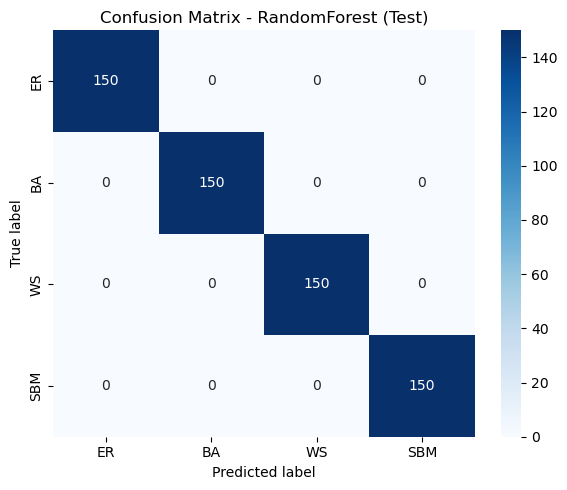

In [18]:
best_model_name = val_results.loc[0, 'model']
best_model = fitted_models[best_model_name]

y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f'Best model (validation): {best_model_name}')
print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test macro-F1: {test_macro_f1:.4f}')

labels = [0, 1, 2, 3]
class_names = ['ER', 'BA', 'WS', 'SBM']
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'Confusion Matrix - {best_model_name} (Test)')
plt.tight_layout()
plt.show()


### Density-Controlled Experiment


Set the same target average degree for all graph generators.

Default density control: average degree = 8 for ER, BA, WS, and SBM.

In [19]:
# Density-controlled setup: same average degree across models
n_dc = 100
density_default = 8
avg_degrees_dc = [density_default, density_default, density_default, density_default]  # ER, BA, WS, SBM
num_graphs_per_class_dc = 1000

graph_dataset_dc = gf.create_graph_dataset(
    n=n_dc,
    avg_degree=avg_degrees_dc,
    num_graphs_per_class=num_graphs_per_class_dc
)
features_dataset_dc = gf.create_features_dataset(graph_dataset_dc)
features_dataset_dc.head()


,mean_degree,std_degree,skew_degree,kurtosis_degree,max_degree,min_degree,assortativity_degree_coeff,mean_cluster_coeff,std_cluster_coeff,max_cluster_coeff,...,mean_e_centrality,std_e_centrality,max_e_centrality,eig_1,eig_2,eig_3,eig_4,eig_5,number_connected_components,target
0,7.68,5.661943,2.197630,4.538063,32.0,4.0,-0.155891,0.178233,0.141857,0.666667,...,0.083127,0.055586,0.301525,8.413785e-16,2.270483,2.355277,2.429022,2.495204,1,1
1,7.94,2.693771,0.269420,-0.108609,16.0,3.0,-0.040346,0.067905,0.059077,0.333333,...,0.093553,0.035324,0.214606,7.453354e-15,1.869460,2.023174,2.311919,2.461648,1,0
2,7.78,2.594533,0.019095,-0.178023,14.0,1.0,0.032868,0.072387,0.079941,0.666667,...,0.092805,0.037247,0.197487,1.128678e-14,0.845569,1.537463,2.111152,2.269494,1,0
3,7.98,2.709170,0.715159,0.908318,16.0,2.0,0.010294,0.094199,0.064063,0.266667,...,0.091425,0.040516,0.231447,1.071733e-14,1.696843,1.939290,2.343082,2.504623,1,0
4,8.08,2.602614,0.511305,0.280514,16.0,2.0,-0.033650,0.084786,0.078381,0.500000,...,0.093699,0.034935,0.216454,1.528998e-15,1.727299,2.109366,2.392876,2.779507,1,0


In [20]:
X_dc = features_dataset_dc.drop(columns=['target'])
y_dc = features_dataset_dc['target']

X_train_val_dc, X_test_dc, y_train_val_dc, y_test_dc = train_test_split(
    X_dc, y_dc, test_size=0.15, random_state=78, stratify=y_dc
)

val_ratio_within_train_val_dc = 0.15 / 0.85
X_train_dc, X_val_dc, y_train_dc, y_val_dc = train_test_split(
    X_train_val_dc,
    y_train_val_dc,
    test_size=val_ratio_within_train_val_dc,
    random_state=78,
    stratify=y_train_val_dc
)

print('Train:', X_train_dc.shape, 'Val:', X_val_dc.shape, 'Test:', X_test_dc.shape)


Train: (2800, 27) Val: (600, 27) Test: (600, 27)


In [21]:
models_dc = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=78, n_jobs=-1),
    'SVM_RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=10, gamma='scale'))
    ])
}

fitted_models_dc = {}
val_rows_dc = []

for name, model in models_dc.items():
    model.fit(X_train_dc, y_train_dc)
    y_val_pred_dc = model.predict(X_val_dc)

    val_rows_dc.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val_dc, y_val_pred_dc),
        'val_macro_f1': f1_score(y_val_dc, y_val_pred_dc, average='macro')
    })
    fitted_models_dc[name] = model

val_results_dc = pd.DataFrame(val_rows_dc).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
val_results_dc


,model,val_accuracy,val_macro_f1
0,RandomForest,1.0,1.0
1,SVM_RBF,1.0,1.0


Best model (validation): RandomForest
Test accuracy: 0.9983
Test macro-F1: 0.9983


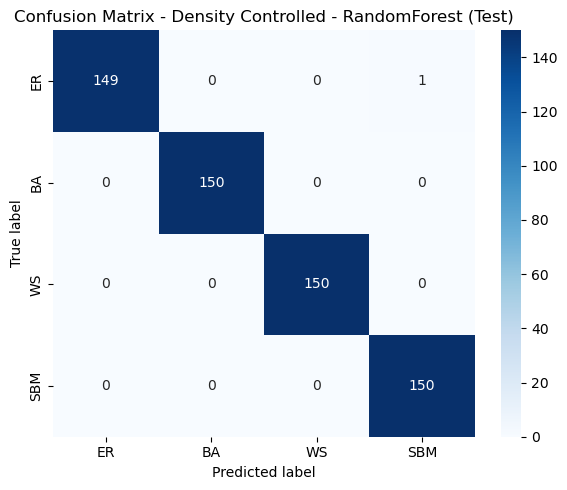

In [22]:
best_model_name_dc = val_results_dc.loc[0, 'model']
best_model_dc = fitted_models_dc[best_model_name_dc]

y_test_pred_dc = best_model_dc.predict(X_test_dc)
test_accuracy_dc = accuracy_score(y_test_dc, y_test_pred_dc)
test_macro_f1_dc = f1_score(y_test_dc, y_test_pred_dc, average='macro')

print(f'Best model (validation): {best_model_name_dc}')
print(f'Test accuracy: {test_accuracy_dc:.4f}')
print(f'Test macro-F1: {test_macro_f1_dc:.4f}')

labels = [0, 1, 2, 3]
class_names = ['ER', 'BA', 'WS', 'SBM']
cm_dc = confusion_matrix(y_test_dc, y_test_pred_dc, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dc, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'Confusion Matrix - Density Controlled - {best_model_name_dc} (Test)')
plt.tight_layout()
plt.show()


### Density-Controlled + Different Graph Sizes


Density-controlled setup with different graph sizes between train and test.

For runtime purposes: training graphs use `n = 50` and test graphs use `n = 100` (instead of 100/200).

In [23]:
# Experiment 3: density-controlled with different sizes between training and testing
density_size = 8
avg_degrees_size = [density_size, density_size, density_size, density_size]  # ER, BA, WS, SBM
num_graphs_per_class_size = 1000

n_train_size = 50
n_test_size = 100

graph_dataset_train_size = gf.create_graph_dataset(
    n=n_train_size,
    avg_degree=avg_degrees_size,
    num_graphs_per_class=num_graphs_per_class_size
)
graph_dataset_test_size = gf.create_graph_dataset(
    n=n_test_size,
    avg_degree=avg_degrees_size,
    num_graphs_per_class=num_graphs_per_class_size
)

features_train_size = gf.create_features_dataset(graph_dataset_train_size)
features_test_size = gf.create_features_dataset(graph_dataset_test_size)

print('Train-size dataset:', features_train_size.shape)
print('Test-size dataset:', features_test_size.shape)


Train-size dataset: (4000, 28)
Test-size dataset: (4000, 28)


In [24]:
X_trainval_size = features_train_size.drop(columns=['target'])
y_trainval_size = features_train_size['target']
X_test_size = features_test_size.drop(columns=['target'])
y_test_size = features_test_size['target']

# Validation is split from the n=50 training dataset only
X_train_size, X_val_size, y_train_size, y_val_size = train_test_split(
    X_trainval_size,
    y_trainval_size,
    test_size=0.15,
    random_state=78,
    stratify=y_trainval_size
)

print('Train:', X_train_size.shape, 'Val:', X_val_size.shape, 'Test:', X_test_size.shape)


Train: (3400, 27) Val: (600, 27) Test: (4000, 27)


In [25]:
models_size = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=78, n_jobs=-1),
    'SVM_RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=10, gamma='scale'))
    ])
}

fitted_models_size = {}
val_rows_size = []

for name, model in models_size.items():
    model.fit(X_train_size, y_train_size)
    y_val_pred_size = model.predict(X_val_size)

    val_rows_size.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val_size, y_val_pred_size),
        'val_macro_f1': f1_score(y_val_size, y_val_pred_size, average='macro')
    })
    fitted_models_size[name] = model

val_results_size = pd.DataFrame(val_rows_size).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
val_results_size


,model,val_accuracy,val_macro_f1
0,RandomForest,1.000000,1.000000
1,SVM_RBF,0.998333,0.998333


Best model (validation): RandomForest
Test accuracy (n=100): 0.7565
Test macro-F1 (n=100): 0.6808


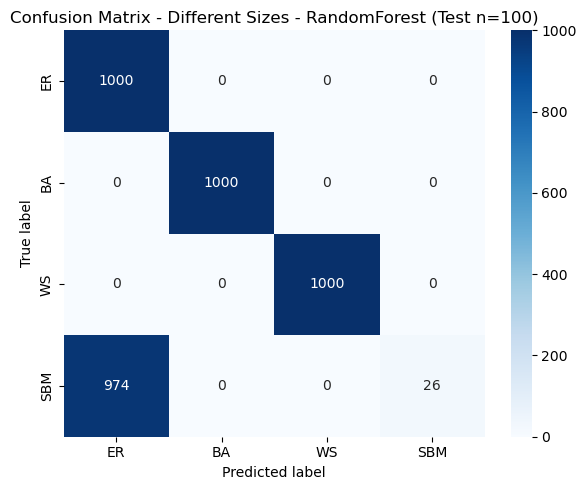

In [26]:
best_model_name_size = val_results_size.loc[0, 'model']
best_model_size = fitted_models_size[best_model_name_size]

y_test_pred_size = best_model_size.predict(X_test_size)
test_accuracy_size = accuracy_score(y_test_size, y_test_pred_size)
test_macro_f1_size = f1_score(y_test_size, y_test_pred_size, average='macro')

print(f'Best model (validation): {best_model_name_size}')
print(f'Test accuracy (n=100): {test_accuracy_size:.4f}')
print(f'Test macro-F1 (n=100): {test_macro_f1_size:.4f}')

labels = [0, 1, 2, 3]
class_names = ['ER', 'BA', 'WS', 'SBM']
cm_size = confusion_matrix(y_test_size, y_test_pred_size, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_size, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'Confusion Matrix - Different Sizes - {best_model_name_size} (Test n=100)')
plt.tight_layout()
plt.show()


### Density-Controlled + Random Edge Perturbations


Density-controlled setup (average degree = 8), then evaluate robustness to noisy edges.

We train on clean graphs and test on both clean and perturbed graphs.

In [27]:
import random

def perturb_graph_edges(G, perturb_fraction=0.05, seed=78):
    """Randomly remove and add edges while keeping graph size and edge count roughly stable."""
    rng = random.Random(seed)
    H = G.copy()

    m = H.number_of_edges()
    num_changes = int(perturb_fraction * m)
    if num_changes == 0:
        return H

    edges = list(H.edges())
    edges_to_remove = rng.sample(edges, min(num_changes, len(edges)))
    H.remove_edges_from(edges_to_remove)

    n = H.number_of_nodes()
    added = 0
    max_attempts = 20 * num_changes
    attempts = 0

    while added < num_changes and attempts < max_attempts:
        u = rng.randrange(n)
        v = rng.randrange(n)
        attempts += 1
        if u == v or H.has_edge(u, v):
            continue
        H.add_edge(u, v)
        added += 1

    return H


In [28]:
# Experiment 4: density-controlled with random edge perturbations
n_noise = 100
density_noise = 8
avg_degrees_noise = [density_noise, density_noise, density_noise, density_noise]
num_graphs_per_class_noise = 1000
perturb_fraction = 0.05  # 5% of edges are rewired

graph_dataset_noise = gf.create_graph_dataset(
    n=n_noise,
    avg_degree=avg_degrees_noise,
    num_graphs_per_class=num_graphs_per_class_noise
)

y_noise = [label for _, label in graph_dataset_noise]
train_val_graphs_noise, test_graphs_noise = train_test_split(
    graph_dataset_noise,
    test_size=0.15,
    random_state=78,
    stratify=y_noise
)

y_train_val_noise = [label for _, label in train_val_graphs_noise]
train_graphs_noise, val_graphs_noise = train_test_split(
    train_val_graphs_noise,
    test_size=(0.15 / 0.85),
    random_state=78,
    stratify=y_train_val_noise
)

test_graphs_noise_perturbed = [
    (perturb_graph_edges(G, perturb_fraction=perturb_fraction, seed=78 + i), t)
    for i, (G, t) in enumerate(test_graphs_noise)
]

features_train_noise = gf.create_features_dataset(train_graphs_noise)
features_val_noise = gf.create_features_dataset(val_graphs_noise)
features_test_noise_clean = gf.create_features_dataset(test_graphs_noise)
features_test_noise_perturbed = gf.create_features_dataset(test_graphs_noise_perturbed)

print('Train:', features_train_noise.shape, 'Val:', features_val_noise.shape)
print('Test clean:', features_test_noise_clean.shape, 'Test perturbed:', features_test_noise_perturbed.shape)


Train: (2800, 28) Val: (600, 28)
Test clean: (600, 28) Test perturbed: (600, 28)


In [29]:
X_train_noise = features_train_noise.drop(columns=['target'])
y_train_noise = features_train_noise['target']
X_val_noise = features_val_noise.drop(columns=['target'])
y_val_noise = features_val_noise['target']
X_test_noise_clean = features_test_noise_clean.drop(columns=['target'])
y_test_noise_clean = features_test_noise_clean['target']
X_test_noise_perturbed = features_test_noise_perturbed.drop(columns=['target'])
y_test_noise_perturbed = features_test_noise_perturbed['target']

models_noise = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=78, n_jobs=-1),
    'SVM_RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=10, gamma='scale'))
    ])
}

fitted_models_noise = {}
val_rows_noise = []

for name, model in models_noise.items():
    model.fit(X_train_noise, y_train_noise)
    y_val_pred_noise = model.predict(X_val_noise)
    val_rows_noise.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val_noise, y_val_pred_noise),
        'val_macro_f1': f1_score(y_val_noise, y_val_pred_noise, average='macro')
    })
    fitted_models_noise[name] = model

val_results_noise = pd.DataFrame(val_rows_noise).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
val_results_noise


,model,val_accuracy,val_macro_f1
0,SVM_RBF,1.000000,1.000000
1,RandomForest,0.998333,0.998333


In [30]:
best_model_name_noise = val_results_noise.loc[0, 'model']
best_model_noise = fitted_models_noise[best_model_name_noise]

y_test_pred_noise_clean = best_model_noise.predict(X_test_noise_clean)
y_test_pred_noise_perturbed = best_model_noise.predict(X_test_noise_perturbed)

robustness_results = pd.DataFrame([
    {
        'dataset': 'Test clean',
        'accuracy': accuracy_score(y_test_noise_clean, y_test_pred_noise_clean),
        'macro_f1': f1_score(y_test_noise_clean, y_test_pred_noise_clean, average='macro')
    },
    {
        'dataset': f'Test perturbed ({int(perturb_fraction * 100)}%)',
        'accuracy': accuracy_score(y_test_noise_perturbed, y_test_pred_noise_perturbed),
        'macro_f1': f1_score(y_test_noise_perturbed, y_test_pred_noise_perturbed, average='macro')
    }
])

print(f'Best model (validation): {best_model_name_noise}')
robustness_results


Best model (validation): SVM_RBF


,dataset,accuracy,macro_f1
0,Test clean,0.996667,0.996667
1,Test perturbed (5%),0.990000,0.989998


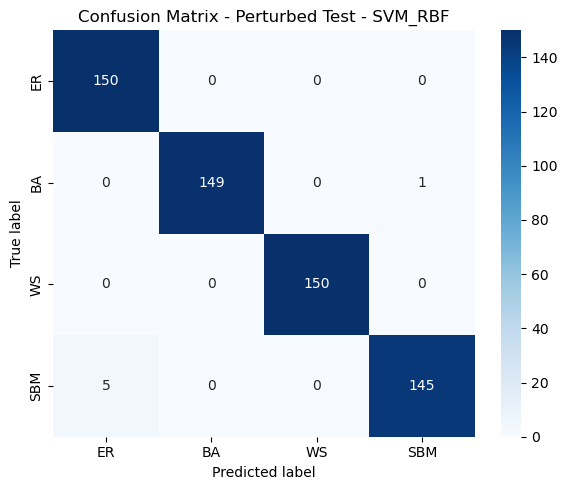

In [31]:
cm_noise_perturbed = confusion_matrix(y_test_noise_perturbed, y_test_pred_noise_perturbed, labels=[0, 1, 2, 3])
class_names = ['ER', 'BA', 'WS', 'SBM']

plt.figure(figsize=(6, 5))
sns.heatmap(cm_noise_perturbed, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'Confusion Matrix - Perturbed Test - {best_model_name_noise}')
plt.tight_layout()
plt.show()
